# 07 Práctica de laboratorio: Métodos ensemble para Adult Income dataset

**Aprendizaje Computacional I**

**Nombre y apellidos:** NOMBRE Y APELLIDOS DEL ESTUDIANTE

# Introducción

En esta práctica trabajaremos con **métodos ensemble**, es decir, modelos que combinan varios clasificadores para obtener predicciones más robustas.

En la práctica anterior estudiamos los **árboles de decisión**.
Un árbol individual es interpretable, pero puede ser inestable y sobreajustar con facilidad.
Los métodos ensemble intentan corregir estas limitaciones combinando muchos árboles.

Estudiaremos:

- árboles de decisión individuales,
- bagging,
- random forest,
- AdaBoost,
- gradient boosting,
- comparación de modelos,
- importancia de variables,
- y validación de resultados.

La práctica está relacionada con los conceptos vistos en teoría:

- modelos débiles y modelos fuertes,
- bagging,
- bootstrap,
- selección aleatoria de variables,
- boosting,
- reducción de varianza,
- reducción de sesgo,
- interpretabilidad mediante importancia de variables.

# Objetivos

Al finalizar esta práctica deberías ser capaz de:

- cargar y preparar un dataset real,
- entrenar un árbol de decisión individual,
- entrenar modelos ensemble,
- comparar bagging, random forest y boosting,
- interpretar métricas de clasificación,
- estudiar el efecto del número de estimadores,
- analizar la importancia de variables,
- y razonar cuándo un ensemble mejora a un árbol individual.

# Dataset: Adult Income

Trabajaremos con el dataset **Adult Income**, disponible en OpenML.

El objetivo será predecir si una persona tiene ingresos anuales superiores a 50 000 dólares a partir de variables demográficas y laborales.

La variable objetivo es:

- `<=50K`
- `>50K`

Este dataset es interesante porque contiene:

- variables numéricas,
- variables categóricas,
- clases desbalanceadas,
- y un problema de clasificación binaria realista.

# Librerías necesarias

Ejecuta la siguiente celda.

In [38]:
# Librerías básicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dataset
from sklearn.datasets import fetch_openml

# División entrenamiento/prueba y validación
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# Preprocesamiento
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Modelos
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

# Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score
)

pd.set_option("display.max_columns", 60)
plt.rcParams["figure.figsize"] = (8, 6)

# Código de estudiante

## Ejercicio 1

Introduce tu código de estudiante.

In [39]:
CODIGO_ESTUDIANTE = 40

np.random.seed(CODIGO_ESTUDIANTE)

# Carga del dataset

## Ejercicio 2

Carga el dataset `adult` usando `fetch_openml`.

Sugerencia:

```python
adult = fetch_openml(name="adult", version=2, as_frame=True)
```

In [40]:
# COMPLETAR
adult = fetch_openml(name="adult", version=2, as_frame=True)

## Ejercicio 3

Muestra en forma de tabla:

- las primeras filas,
- el número de ejemplos,
- el número de columnas,
- los nombres de las columnas.

In [41]:
# COMPLETAR
datos = pd.DataFrame(data=adult.data, columns=adult.categories)
datos["class"] = adult.target

display(datos.head())
print(f"Número de filas: {datos.shape[0]}")
print(f"Número de columnas: {datos.shape[1]}")
print(f"Nombre de las columnas: {datos.columns}")

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


Número de filas: 48842
Número de columnas: 15
Nombre de las columnas: Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'class'],
      dtype='str')


# Selección y preparación inicial

## Ejercicio 4

Crea un `DataFrame` llamado `datos` con todos los datos del dataset.

Después, elimina las filas con valores perdidos.

Muestra:

- el tamaño original,
- el tamaño tras eliminar valores perdidos,
- el número de filas eliminadas.

In [42]:
# COMPLETAR
original = datos.shape[0]
datos = datos.dropna()
print(f"Filas antes: {original}. Filas despues: {datos.shape[0]}. Filas eliminadas {original - datos.shape[0]}")

Filas antes: 48842. Filas despues: 45222. Filas eliminadas 3620


## Ejercicio 5

Estudia la distribución de la variable objetivo `class`.

Pregunta:

1. ¿Está el dataset balanceado?
2. ¿Por qué puede ser útil mirar métricas distintas de la accuracy?

In [43]:
# COMPLETAR
distribucion = datos["class"].value_counts()
print(f"Distribución de la variable objetivo: {distribucion}")

Distribución de la variable objetivo: class
<=50K    34014
>50K     11208
Name: count, dtype: int64


**Respuesta.**

Si, hay 34000 filas de una clase y 11200 de otra, estan desbalanceadas. Con un desbalanceo así, el accuracy puede mentir: un modelo puede predecir siempre $\le$ 50K y acertaría el 76% de las veces sin haber aprendido nada. Usar métricas como Precision, Recall o F1-score permite evaluar si el modelo es realmente capaz de detectar la clase minoritaria (> 50K) sin generar falsos positivos ni ignorar a los usuarios de altos ingresos.

# Variables predictoras y variable objetivo

## Ejercicio 6

Separa:

- matriz de variables predictoras `X`,
- vector de etiquetas `y`.

Convierte la variable objetivo en binaria:

- `0` para `<=50K`
- `1` para `>50K`

In [44]:
# COMPLETAR
X = datos.drop(columns=["class"]).copy()
y = datos["class"].copy()

y = y.apply(lambda x : 0 if x == "<=50K" else 1)
display(y.head())

0    0
1    0
2    1
3    1
5    0
Name: class, dtype: category
Categories (2, int64): [0, 1]

## Ejercicio 7

Identifica automáticamente:

- variables numéricas,
- variables categóricas.

Después, crea un preprocesador con `ColumnTransformer` que aplique `OneHotEncoder` a las variables categóricas y deje pasar las variables numéricas.

In [45]:
# COMPLETAR
numericos = X.select_dtypes(include=["int64", "float64"]).columns
categoricos = X.select_dtypes(exclude=["int64", "float64"]).columns

preprocesador = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categoricos)],
    remainder="passthrough"
)

# División entrenamiento/prueba

## Ejercicio 8

Divide los datos en:

- entrenamiento (80%)
- prueba (20%)

Usa:

- `random_state = CODIGO_ESTUDIANTE`
- `stratify = y`

In [46]:
# COMPLETAR
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.8,
    test_size=0.2,
    random_state=CODIGO_ESTUDIANTE,
    stratify=y
)

# Modelo base: árbol de decisión

## Ejercicio 9

Entrena un árbol de decisión individual usando:

- `max_depth = 5`
- `random_state = CODIGO_ESTUDIANTE`

Usa un `Pipeline` que incluya:

- preprocesamiento,
- modelo.

In [47]:
# COMPLETAR
ad = DecisionTreeClassifier(max_depth=5, random_state=CODIGO_ESTUDIANTE)
pipeline = Pipeline(steps=[("preprocesador", preprocesador), ("ad", ad)])
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
y_probs = pipeline.predict_proba(X_test)[:, 0]

## Ejercicio 10

Calcula para el árbol de decisión:

- accuracy,
- precision,
- recall,
- F1-score,
- AUC.

Muestra resultado en formato tabla. 

In [48]:
# COMPLETAR
accuracyAD = accuracy_score(y_test, y_pred)
precisionAD = precision_score(y_test, y_pred)
recallAD = recall_score(y_test, y_pred)
f1AD = f1_score(y_test, y_pred)
aucAD = roc_auc_score(y_test == 0, y_probs)

print(f"Accuracy: {accuracyAD:.4f}")
print(f"Precision: {precisionAD:.4f}")
print(f"Recall: {recallAD:.4f}")
print(f"F1-score: {f1AD:.4f}")
print(f"AUC: {aucAD:.4f}")

Accuracy: 0.8395
Precision: 0.7687
Recall: 0.5040
F1-score: 0.6088
AUC: 0.8740


## Ejercicio 11

Representa la matriz de confusión del árbol.

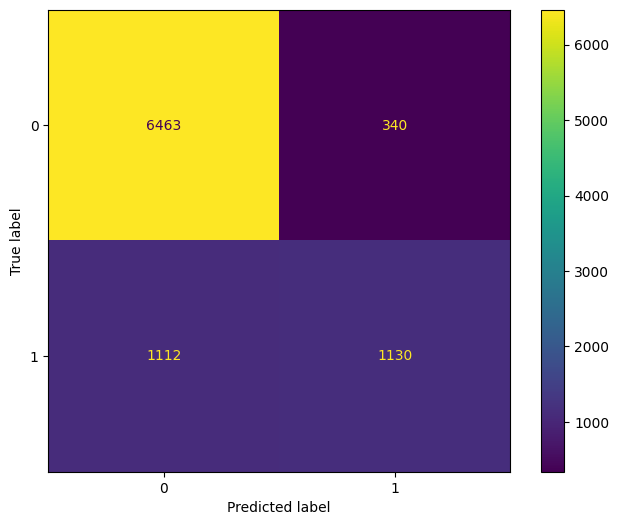

In [49]:
# COMPLETAR
cm = confusion_matrix(y_test, y_pred)
cmd = ConfusionMatrixDisplay(cm)

cmd.plot()
plt.show()

## Ejercicio 12

Pregunta:

1. ¿Qué tipo de error comete más el árbol?
2. ¿Qué métrica te parece más informativa en este dataset?
3. ¿Por qué la accuracy puede ser engañosa?

**Respuesta.**

1. El árbol comete errores de falsos negativos, porque el recall es muy bajo 50%, lo que significa que el modelo es incapaz de detectar a casi la mitad de las personas que realmente ganan más de 50K, clasificándolas en la categoría de bajos ingresos.
2. La métrica más informativa es el F1-score 0.6088, ya que al ser la media entre precision y recall, proporciona una visión realista y equilibrada del rendimiento del modelo sobre la clase minoritaria (>50K), penalizando el impacto que tiene el recall.
3. Porque al estar el dataset desbalanceado, un modelo puede predecir un 76% de accuracy sin aprender nada. En este caso, la accuracy del 84% camufla por el hecho de que el modelo está fallando en la mitad de los casos de la clase de altos ingresos.

# Bagging

## Ejercicio 13

Entrena un modelo de **bagging** usando como estimador base un árbol de decisión.

Usa:

- `n_estimators = 50`
- `random_state = CODIGO_ESTUDIANTE`

In [50]:
# COMPLETAR
bag = BaggingClassifier(n_estimators=50, random_state=CODIGO_ESTUDIANTE)
pipeline = Pipeline(steps=[("preprocesador", preprocesador), ("bag", bag)])
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
y_probs = pipeline.predict_proba(X_test)[:, 0]

## Ejercicio 14

Evalúa el modelo de bagging con las mismas métricas que el árbol individual. 
Muestra resultado en formato tabla. 

In [51]:
# COMPLETAR
accuracyBAG = accuracy_score(y_test, y_pred)
precisionBAG = precision_score(y_test, y_pred)
recallBAG = recall_score(y_test, y_pred)
f1BAG = f1_score(y_test, y_pred)
aucBAG = roc_auc_score(y_test == 0, y_probs)

print(f"Accuracy: {accuracyBAG:.4f}")
print(f"Precision: {precisionBAG:.4f}")
print(f"Recall: {recallBAG:.4f}")
print(f"F1-score: {f1BAG:.4f}")
print(f"AUC: {aucBAG:.4f}")

Accuracy: 0.8439
Precision: 0.7205
Recall: 0.6048
F1-score: 0.6576
AUC: 0.8911


## Ejercicio 15

Pregunta:

1. ¿Mejora bagging al árbol individual?
2. ¿Por qué bagging puede reducir la varianza de un árbol?

**Respuesta.**

1. Sí, el recall sube de forma drástica a 0.6048, logrando capturar un 10% más de personas con altos ingresos. Esto eleva el F1-score al 0.6576 y el AUC al 0.8911, demostrando ser un modelo mucho más robusto.
2. Porque entrena múltiples árboles en paralelo con distintas submuestras aleatorias y luego promedia sus predicciones. Al combinar las respuestas de muchos árboles, los errores individuales y el ruido de cada uno se cancelan entre sí, suavizando el modelo final y estabilizando sus predicciones ante datos nuevos.

# Random Forest

## Ejercicio 16

Entrena un modelo **Random Forest** usando:

- `n_estimators = 100`
- `max_depth = None`
- `random_state = CODIGO_ESTUDIANTE`
- `n_jobs = -1`

In [52]:
# COMPLETAR
rf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=CODIGO_ESTUDIANTE, n_jobs=-1)
pipeline = Pipeline(steps=[("preprocesador", preprocesador), ("rf", rf)])
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
y_probs = pipeline.predict_proba(X_test)[:, 0]

## Ejercicio 17

Evalúa el modelo Random Forest. Muestra resultado en formato tabla. 

In [53]:
# COMPLETAR
accuracyRF = accuracy_score(y_test, y_pred)
precisionRF = precision_score(y_test, y_pred)
recallRF = recall_score(y_test, y_pred)
f1RF = f1_score(y_test, y_pred)
aucRF = roc_auc_score(y_test == 0, y_probs)

print(f"Accuracy: {accuracyRF:.4f}")
print(f"Precision: {precisionRF:.4f}")
print(f"Recall: {recallRF:.4f}")
print(f"F1-score: {f1RF:.4f}")
print(f"AUC: {aucRF:.4f}")

Accuracy: 0.8450
Precision: 0.7215
Recall: 0.6102
F1-score: 0.6612
AUC: 0.8937


## Ejercicio 18

Pregunta:

1. ¿En qué se diferencia Random Forest de bagging con árboles?
2. ¿Por qué seleccionar subconjuntos aleatorios de variables puede mejorar el ensemble?

**Respuesta.**

1. A diferencia de Bagging (que evalúa todas las variables en cada división), Random Forest añade una capa extra de aleatoriedad al forzar a cada nodo a elegir el mejor corte entre un subconjunto aleatorio de variables (max_features). Haciendo que el bosque sea mucho más diverso y robusto que un simple agregado de árboles independientes.
2. Evita que las variables dominantes eclipsen al resto y hagan que todos los árboles del ensemble sean copias casi idénticas. Al bloquear temporalmente esas variables estrella en algunos nodos, obliga al algoritmo a descubrir patrones ocultos en variables secundarias, aumentando la diversidad del modelo y su capacidad de generalización.

# AdaBoost

## Ejercicio 19

Entrena un modelo **AdaBoost** usando:

- árboles de decisión de profundidad 1 como estimadores débiles,
- `n_estimators = 100`,
- `learning_rate = 0.5`,
- `random_state = CODIGO_ESTUDIANTE`.

In [54]:
# COMPLETAR
ab = AdaBoostClassifier(n_estimators=100, learning_rate=0.5, random_state=CODIGO_ESTUDIANTE)
pipeline = Pipeline(steps=[("preprocesador", preprocesador), ("ab", ab)])
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
y_probs = pipeline.predict_proba(X_test)[:, 0]

## Ejercicio 20

Evalúa el modelo AdaBoost. Muestra resultado en formato tabla. 

In [55]:
# COMPLETAR
accuracyAB = accuracy_score(y_test, y_pred)
precisionAB = precision_score(y_test, y_pred)
recallAB = recall_score(y_test, y_pred)
f1AB = f1_score(y_test, y_pred)
aucAB = roc_auc_score(y_test == 0, y_probs)

print(f"Accuracy: {accuracyAB:.4f}")
print(f"Precision: {precisionAB:.4f}")
print(f"Recall: {recallAB:.4f}")
print(f"F1-score: {f1AB:.4f}")
print(f"AUC: {aucAB:.4f}")

Accuracy: 0.8427
Precision: 0.7675
Recall: 0.5241
F1-score: 0.6228
AUC: 0.8992


## Ejercicio 21

Pregunta:

1. ¿Qué significa que AdaBoost combine clasificadores débiles?
2. ¿Qué intenta hacer AdaBoost con los ejemplos mal clasificados?

**Respuesta.**

1. En lugar de usar un modelo complejo, entrena de forma secuencial árboles muy simples y con poca capacidad predictiva por sí solos. Al final, suma el criterio de todos ellos mediante una votación ponderada, donde los que demostraron mayor acierto tienen más peso, logrando así un clasificador final fuerte y preciso.
2. En cada iteración, aumenta el peso de los ejemplos que el modelo anterior clasificó de forma errónea y disminuye el de los acertados. Esto obliga al siguiente árbol débil de la secuencia a enfocarse de manera prioritaria en esos datos difíciles, intentando corregir los fallos acumulados hasta el momento.

# Gradient Boosting

## Ejercicio 22

Entrena un modelo **Gradient Boosting** usando:

- `n_estimators = 100`
- `learning_rate = 0.1`
- `max_depth = 3`
- `random_state = CODIGO_ESTUDIANTE`

In [56]:
# COMPLETAR
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=CODIGO_ESTUDIANTE)
pipeline = Pipeline(steps=[("preprocesador", preprocesador), ("gb", gb)])
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
y_probs = pipeline.predict_proba(X_test)[:, 0]

## Ejercicio 23

Evalúa el modelo Gradient Boosting. Muestra resultado en formato tabla. 

In [57]:
# COMPLETAR
accuracyGB = accuracy_score(y_test, y_pred)
precisionGB = precision_score(y_test, y_pred)
recallGB = recall_score(y_test, y_pred)
f1GB = f1_score(y_test, y_pred)
aucGB = roc_auc_score(y_test == 0, y_probs)

print(f"Accuracy: {accuracyGB:.4f}")
print(f"Precision: {precisionGB:.4f}")
print(f"Recall: {recallGB:.4f}")
print(f"F1-score: {f1GB:.4f}")
print(f"AUC: {aucGB:.4f}")

Accuracy: 0.8564
Precision: 0.7792
Recall: 0.5870
F1-score: 0.6695
AUC: 0.9115


## Ejercicio 24

Pregunta:

1. ¿Qué diferencia conceptual hay entre bagging y boosting?
2. ¿Por qué boosting puede lograr modelos muy precisos?

**Respuesta.**

1. Bagging entrena múltiples modelos independientes en paralelo sobre distintas muestras aleatorias de los datos y luego promedia sus predicciones para reducir la varianza. Boosting, entrena los modelos de forma secuencial, donde cada nuevo modelo se diseña específicamente para corregir los errores cometidos por los modelos anteriores, reduciendo el sesgo.
2. Porque es un algoritmo de aprendizaje iterativo y adaptativo que optimiza activamente los puntos débiles del sistema. Al focalizar los recursos de los nuevos clasificadores en los ejemplos más difíciles y mal clasificados del dataset, minimiza el error global paso a paso, logrando ajustar fronteras de decisión extremadamente complejas y precisas.

# Comparación final de modelos

## Ejercicio 25

Construye una tabla resumen con los resultados de:

- árbol individual,
- bagging,
- random forest,
- AdaBoost,
- gradient boosting.

La tabla debe incluir:

- accuracy,
- precision,
- recall,
- F1-score,
- AUC.

In [58]:
# COMPLETAR
res = pd.DataFrame(columns=["Algoritmo", "Accuracy", "Precision", "Recall", "F1-score", "AUC"])
res.loc[len(res)] = ["Árbol de decision", accuracyAD, precisionAD, recallAD, f1AD, aucAD]
res.loc[len(res)] = ["Bagging", accuracyBAG, precisionBAG, recallBAG, f1BAG, aucBAG]
res.loc[len(res)] = ["Random Forest", accuracyRF, precisionRF, recallRF, f1RF, aucRF]
res.loc[len(res)] = ["AdaBoost", accuracyAB, precisionAB, recallAB, f1AB, aucAB]
res.loc[len(res)] = ["Gradient Boosting", accuracyGB, precisionGB, recallGB, f1GB, aucGB]

display(res)

,Algoritmo,Accuracy,Precision,Recall,F1-score,AUC
0,Árbol de decision,0.839469,0.768707,0.504014,0.608836,0.874040
1,Bagging,0.843892,0.720510,0.604817,0.657614,0.891063
2,Random Forest,0.844997,0.721519,0.610169,0.661189,0.893684
3,AdaBoost,0.842676,0.767472,0.524086,0.622847,0.899243
4,Gradient Boosting,0.856385,0.779159,0.586976,0.669550,0.911474


## Ejercicio 26

Pregunta:

1. ¿Cuál es el mejor modelo según accuracy?
2. ¿Cuál es el mejor modelo según F1-score?
3. ¿Coinciden?
4. ¿Qué modelo elegirías y por qué?

**Respuesta.**

1. Gradient Boosting
2. Gradient Boosting
3. Si
4. Gradient Boosting ya que es el que obtiene mejores métricas

# Efecto del número de estimadores

## Ejercicio 27

Estudia el efecto de `n_estimators` en Random Forest.

Prueba al menos:

$$
n\\_estimators \\in \\{10,25,50,100,200\\}
$$

Calcula el F1-score en el conjunto de prueba para cada valor.

In [59]:
# COMPLETAR
n_estimators = [10, 25, 50, 100, 200]
res_rf2 = []

for n in n_estimators:
    rf2 = RandomForestClassifier(n_estimators=n, random_state=CODIGO_ESTUDIANTE)
    pipeline = Pipeline(steps=[("preprocesador", preprocesador), ("rf2", rf2)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    res_rf2.append({
        "n": n,
        "F1-score": f1_score(y_test, y_pred)
    })

res_rf2 = pd.DataFrame(res_rf2)

## Ejercicio 28

Representa gráficamente el F1-score frente al número de estimadores.

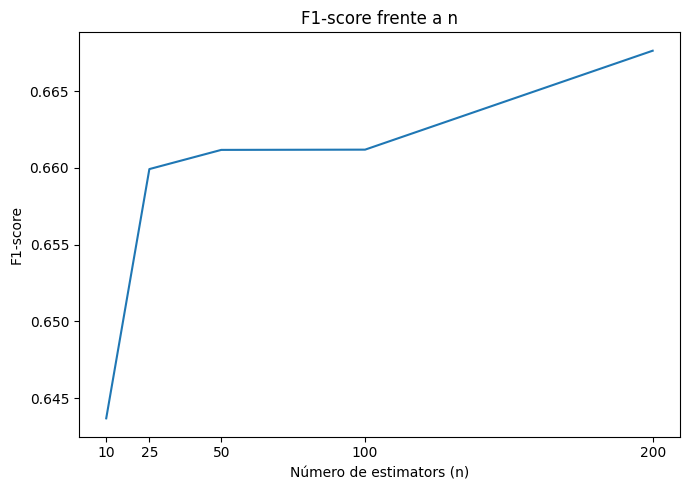

In [60]:
# COMPLETAR
plt.figure(figsize=(7, 5))
plt.plot(res_rf2["n"], res_rf2["F1-score"])
plt.title("F1-score frente a n")
plt.xlabel("Número de estimators (n)")
plt.ylabel("F1-score")
plt.xticks(n_estimators)
plt.tight_layout()
plt.show()

## Ejercicio 29

Pregunta:

1. ¿Mejora siempre el rendimiento al aumentar `n_estimators`?
2. ¿Qué coste tiene aumentar demasiado el número de árboles?

**Respuesta.**

1. No. Al principio, añadir más árboles mejora notablemente las métricas porque estabiliza las predicciones del conjunto, pero llega un punto donde el rendimiento se estabiliza. 2. Añadir más estimadores ya no aporta ninguna mejora real al modelo, solo coste computacional y eficiencia.

# Importancia de variables

## Ejercicio 30

Obtén la importancia de variables del modelo Random Forest.

Ten en cuenta que, después de aplicar `OneHotEncoder`, las variables categóricas se transforman en varias columnas.

Sugerencia:

- usa `get_feature_names_out()` en el preprocesador.

In [61]:
# COMPLETAR
columnas = pipeline.named_steps["preprocesador"].get_feature_names_out()
importancias = pipeline.named_steps["rf2"].feature_importances_

importancias = pd.DataFrame({
    'Variable': columnas,
    'Importancia': importancias
})

importancias.sort_values(by="Importancia", ascending=False)

,Variable,Importancia
99,remainder__fnlwgt,1.696396e-01
98,remainder__age,1.515635e-01
101,remainder__capital-gain,9.609701e-02
103,remainder__hours-per-week,8.416246e-02
25,cat__marital-status_Married-civ-spouse,6.323047e-02
...,...,...
94,cat__native-country_Trinadad&Tobago,5.825078e-05
20,cat__education_Preschool,5.746662e-05
84,cat__native-country_Outlying-US(Guam-USVI-etc),3.764152e-05
72,cat__native-country_Honduras,2.667083e-05


## Ejercicio 31

Representa las 15 variables más importantes.

In [62]:
# COMPLETAR
importancias.sort_values(by="Importancia", ascending=False).head(15)

,Variable,Importancia
99,remainder__fnlwgt,0.169640
98,remainder__age,0.151563
101,remainder__capital-gain,0.096097
103,remainder__hours-per-week,0.084162
25,cat__marital-status_Married-civ-spouse,0.063230
100,remainder__education-num,0.061142
44,cat__relationship_Husband,0.037828
102,remainder__capital-loss,0.031694
27,cat__marital-status_Never-married,0.024320
33,cat__occupation_Exec-managerial,0.019652


## Ejercicio 32

Pregunta:

1. ¿Qué variables parecen más importantes?
2. ¿Tiene sentido desde el punto de vista del problema?
3. ¿Qué limitaciones tiene la importancia de variables basada en árboles?

**Respuesta.**

1. remainder__age y remainder__fnlwgt
2. Sí, La edad refleja la madurez y la experiencia laboral acumulada de una persona, factores que están ligados a la capacidad de alcanzar un sueldo alto (>50K).
3. Su principal limitación es el sesgo hacia variables continuas o con alta cardinalidad. Como estas variables tienen muchísimos valores numéricos únicos, el algoritmo dispone de infinitos puntos de corte para dividir los nodos y reducir la impureza, lo que infla su importancia real frente a variables categóricas que podrían ser más determinantes.

# Validación cruzada

## Ejercicio 33

Evalúa mediante validación cruzada de 5 particiones dos modelos:

- árbol individual,
- random forest.

Usa como métrica el F1-score.

In [65]:
# COMPLETAR
cv_ad = cross_val_score(Pipeline(steps=[("preprocesador", preprocesador), ("ad", ad)]), X_train, y_train, cv=5, scoring="f1")
cv_rf = cross_val_score(Pipeline(steps=[("preprocesador", preprocesador), ("rf", rf)]), X_train, y_train, cv=5, scoring="f1")

print(f"F1 de ad: {cv_ad.mean():.4f}")
print(f"F1 de rf: {cv_rf.mean():.4f}")

F1 de ad: 0.6289
F1 de rf: 0.6801


## Ejercicio 34

Pregunta:

1. ¿Qué modelo tiene mejor F1 medio?
2. ¿Cuál parece más estable?
3. ¿Por qué conviene usar validación cruzada?

**Respuesta.**

1. Random forest tiene mejor f1
2. El Random Forest, ya que al promediar las predicciones de los árboles independientes entrenados con submuestras distintas, el algoritmo neutraliza los errores aleatorios, presentando una varianza y dispersión de resultados mucho menor entre las 5 particiones que un único árbol.
3. Porque proporciona una evaluación del modelo mucho más robusta y libre de sesgos por azar. En lugar de confiar en una única partición que podría ser inusualmente fácil o difícil, promediar 5 bloques distintos garantiza que estimemos el rendimiento real que tendrá el modelo al enfrentarse a datos nuevos en el futuro.

# Nota opcional sobre XGBoost

En teoría puede aparecer XGBoost como una implementación muy usada de gradient boosting.

En esta práctica no se exige usar XGBoost porque no siempre está instalado en todos los entornos.

Si tienes instalado `xgboost`, puedes intentar entrenar un modelo `XGBClassifier` y compararlo con los anteriores.

In [69]:
# EJERCICIO OPCIONAL
# COMPLETAR SOLO SI TIENES INSTALADO xgboost

from xgboost import XGBClassifier

xgb = XGBClassifier(random_state = CODIGO_ESTUDIANTE)
pipeline = Pipeline(steps=[("preprocesador", preprocesador), ("xgb", xgb)])
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
y_probs = pipeline.predict_proba(X_test)[:, 0]

In [70]:
accuracyXGB = accuracy_score(y_test, y_pred)
precisionXGB = precision_score(y_test, y_pred)
recallXGB = recall_score(y_test, y_pred)
f1XGB = f1_score(y_test, y_pred)
aucXGB = roc_auc_score(y_test == 0, y_probs)

print(f"Accuracy: {accuracyXGB:.4f}")
print(f"Precision: {precisionXGB:.4f}")
print(f"Recall: {recallXGB:.4f}")
print(f"F1-score: {f1XGB:.4f}")
print(f"AUC: {aucXGB:.4f}")

Accuracy: 0.8609
Precision: 0.7625
Recall: 0.6374
F1-score: 0.6944
AUC: 0.9222


# Ejercicio final de reflexión

Responde brevemente a las siguientes preguntas.

1. ¿Qué problema intenta resolver bagging?
2. ¿Qué problema intenta resolver boosting?
3. ¿Por qué Random Forest suele funcionar mejor que un árbol individual?
4. ¿Qué ventajas tienen los métodos ensemble?
5. ¿Qué inconvenientes tienen?
6. ¿Por qué los ensembles suelen ser menos interpretables que un árbol individual?
7. ¿Qué modelo de esta práctica recomendarías para este problema?

**Respuesta.**

1. El problema de la alta varianza y la inestabilidad de los modelos. Al entrenar árboles en paralelo con muestras aleatorias y promediar sus predicciones, cancela los errores individuales y el ruido, evitando que el modelo sufra de sobreajuste.
2. El problema del alto sesgo de los modelos sencillos o débiles. Al entrenar los árboles secuencialmente, obligando a cada uno a concentrarse en corregir los errores del anterior, reduce el error sistemático y logra ajustar fronteras de decisión extremadamente complejas.
3. Porque reduce la correlación entre sus árboles al forzarlos a elegir variables de forma aleatoria en cada nodo. Mientras que un árbol individual es rígido y se rompe ante pequeños cambios en los datos, el bosque combina la sabiduría de cientos de árboles diversos que promedian sus errores.
4. Capacidad predictiva muy superior, son estables ante datos nuevos y resisten mucho mejor el sobreajuste que los modelos simples. Además, permiten extraer la importancia de las variables combinando el criterio de todo el conjunto.
5. Tienen un alto coste computacional, heredan sesgos si los datos de origen no se limpian bien y destruyen por completo la facilidad de visualización del modelo.
6. Porque un árbol individual es una "caja blanca" de la que puedes extraer reglas lógicas simples en un papel. Un ensemble es una "caja negra" compuesta por cientos de árboles votando a la vez; seguir el rastro matemático de cada decisión a través de miles de ramas simultáneas es humanamente imposible.
7. Random Forest, ofrece un 0.6801 de F1-score medio en validación cruzada y, al ser un dataset desbalanceado, su robustez y equilibrio nativo lo convierten en la opción más segura y eficiente para producción.

# Entrega

La entrega debe incluir:

- el notebook completado,
- todas las gráficas,
- las tablas de métricas,
- las respuestas razonadas,
- y la interpretación de resultados.

No basta con ejecutar código: las respuestas deben explicar qué significan los resultados obtenidos.

# Comentario sobre el código de estudiante

Todos los estudiantes trabajarán con el mismo dataset completo, pero usarán distintos valores de `random_state` derivados de su código de estudiante.

Esto hace que:

- las particiones entrenamiento/prueba cambien ligeramente,
- algunos modelos ensemble usen semillas distintas,
- los resultados numéricos no sean exactamente iguales,
- pero todos trabajen sobre el mismo problema y puedan compararse resultados.

Esta estrategia facilita:

- la corrección,
- la comparación en clase,
- y evita que algunos estudiantes reciban subconjuntos demasiado fáciles o difíciles.